# Analyse de drift

Ce notebook compare les journaux de production avec le jeu de données de référence et met en évidence les variables ayant subi une dérive.

**Sources de données :**
- logs/predictions.jsonl
- data/data_final.parquet

**Résumé de la méthode :**
- Variables numériques : test KS avec correction FDR
- Variables catégorielles : PSI

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "monitoring").exists():
    for parent in ROOT.parents:
        if (parent / "monitoring").exists():
            ROOT = parent
            break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from monitoring.drift_report import CATEGORICAL_FEATURES, compute_drift_summary


In [2]:
logs_path = Path("../logs/predictions.jsonl")
reference_path = Path("../data/data_final.parquet")

params = dict(
    sample_size=50000,
    psi_threshold=0.2,
    score_bins=30,
    min_prod_samples=500,
    psi_eps=1e-4,
    min_category_share=0.01,
    fdr_alpha=0.05,
    min_drift_features=1,
)

if not logs_path.exists():
    raise FileNotFoundError(logs_path)
if not reference_path.exists():
    raise FileNotFoundError(reference_path)


In [3]:
summary = compute_drift_summary(
    log_path=logs_path,
    reference_path=reference_path,
    **params,
)

summary_df = summary["summary_df"].sort_values("drift_detected", ascending=False)
summary_df


,feature,type,ks_stat,p_value,p_value_fdr,drift_detected,n_prod,n_ref,note,psi
0,EXT_SOURCE_2,numeric,0.5495,0.0,0.0,True,683,49907,,NaN
1,EXT_SOURCE_3,numeric,0.7884,0.0,0.0,True,678,40250,,NaN
3,EXT_SOURCE_1,numeric,0.4468,0.0,0.0,True,670,22738,,NaN
9,FLAG_OWN_CAR,categorical,NaN,NaN,NaN,True,683,50000,,1.067
2,AMT_ANNUITY,numeric,NaN,NaN,NaN,False,1,49996,insufficient_sample,NaN
4,CODE_GENDER,categorical,NaN,NaN,NaN,False,683,50000,,0.062
5,DAYS_EMPLOYED,numeric,NaN,NaN,NaN,False,27,40696,insufficient_sample,NaN
6,AMT_CREDIT,numeric,NaN,NaN,NaN,False,1,50000,insufficient_sample,NaN
7,AMT_GOODS_PRICE,numeric,NaN,NaN,NaN,False,1,49962,insufficient_sample,NaN
8,DAYS_BIRTH,numeric,NaN,NaN,NaN,False,1,50000,insufficient_sample,NaN


In [4]:
print("Production sample size:", summary["n_prod"])
print("Reference sample size:", summary["n_ref"])
print("Drift features:", summary["drift_features"])
print("Drift count:", summary["drift_count"])
print("Overall drift:", summary["overall_drift"])


Production sample size: 683
Reference sample size: 50000
Drift features: ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'FLAG_OWN_CAR']
Drift count: 4
Overall drift: True


## Interprétation

* Concentrez-vous sur les variables signalées comme dérivantes dans `summary_df`.
* Si de nombreuses variables affichent `insufficient_sample`, augmentez la fenêtre d’échantillonnage en production.
* Gardez à l’esprit que les journaux ne contiennent que les entrées requises ; les autres variables ne sont pas suivies.

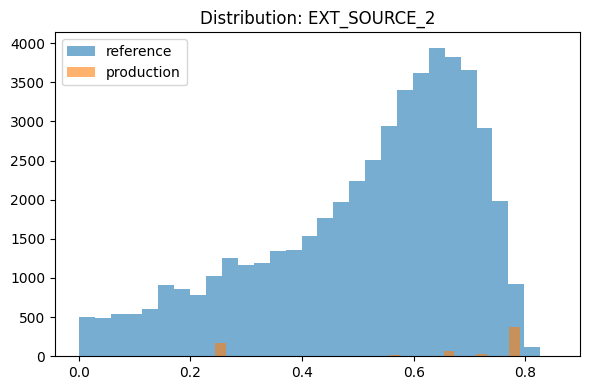

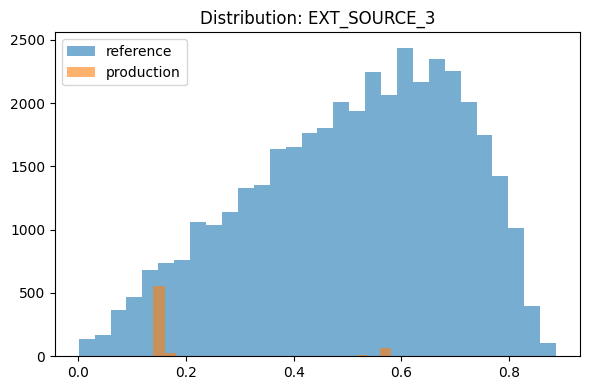

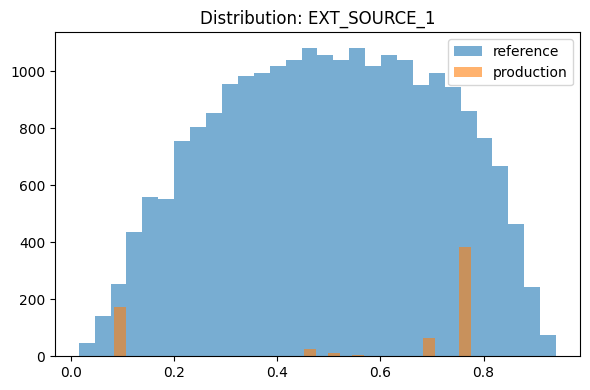

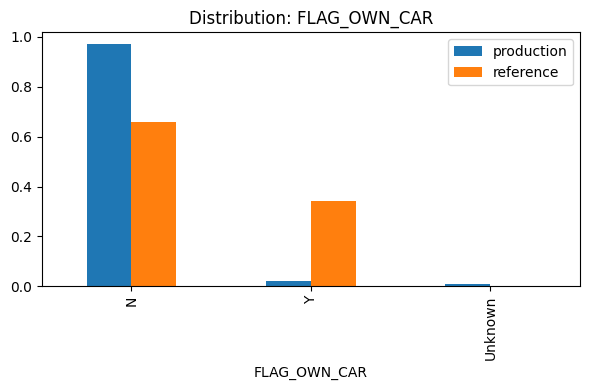

In [5]:
production_df = summary["production_df"]
reference_df = summary["reference_df"]

drift_features = summary["drift_features"] or summary_df["feature"].tolist()

for feature in drift_features:
    if feature not in production_df.columns or feature not in reference_df.columns:
        continue

    plt.figure(figsize=(6, 4))
    if feature in CATEGORICAL_FEATURES:
        prod_freq = production_df[feature].fillna("Unknown").value_counts(normalize=True)
        ref_freq = reference_df[feature].fillna("Unknown").value_counts(normalize=True)
        plot_df = pd.DataFrame({"production": prod_freq, "reference": ref_freq}).fillna(0)
        plot_df.sort_values("reference", ascending=False).plot(kind="bar", ax=plt.gca())
        plt.title(f"Distribution: {feature}")
        plt.tight_layout()
    else:
        plt.hist(reference_df[feature].dropna(), bins=30, alpha=0.6, label="reference")
        plt.hist(production_df[feature].dropna(), bins=30, alpha=0.6, label="production")
        plt.title(f"Distribution: {feature}")
        plt.legend()
        plt.tight_layout()
    plt.show()
